# AI/ML Medical Device Summary — Descriptive Statistics

Unified summary of `aiml_df` (FDA AI/ML-enabled device submissions): data types, measurement levels, counts, central tendency, spread, skewness, and IQR outliers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

DATA_PATH = (
    Path("..")
    / "AI Medical Device Summary Database"
    / "medical-ai-evaluation"
    / "database"
    / "aiml_dfs"
    / "aiml_df.csv"
)

aiml_df_raw = pd.read_csv(DATA_PATH)
print(f"Original shape: {aiml_df_raw.shape[0]:,} rows × {aiml_df_raw.shape[1]} columns")

# Coerce numeric fields stored as strings
aiml_df_raw["num_sites"] = pd.to_numeric(aiml_df_raw["num_sites"], errors="coerce")
aiml_df_raw["subtype_analysis"] = pd.to_numeric(
    aiml_df_raw["subtype_analysis"], errors="coerce"
)

CATEGORICAL_TO_ENCODE = [
    "body_area",
    "modality",
    "review_panel",
    "decision",
    "type",
    "regulation_medical_specialty",
]

aiml_df = pd.get_dummies(
    aiml_df_raw,
    columns=CATEGORICAL_TO_ENCODE,
    dtype=int,
)
print(f"Encoded shape: {aiml_df.shape[0]:,} rows × {aiml_df.shape[1]} columns")
aiml_df.filter(regex=r"^(body_area_|modality_|review_panel_|decision_|type_|regulation_medical_specialty_)").head()

Original shape: 130 rows × 35 columns
Encoded shape: 130 rows × 101 columns


,decision_date,body_area_Abdomen,body_area_Arteries,body_area_Bladder,body_area_Body,body_area_Bone,body_area_Brain,body_area_Breast,body_area_Cellular,body_area_Cervical Spine,...,decision_se - with limitations (sesu),decision_substantially equivalent (sese),type_direct,type_special,type_traditional,regulation_medical_specialty_cardiovascular,regulation_medical_specialty_hematology,regulation_medical_specialty_microbiology,regulation_medical_specialty_ophthalmic,regulation_medical_specialty_radiology
0,7/19/17,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,6/12/18,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,2/13/18,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,4/11/18,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,5/24/18,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


## Unified Summary Table

Key categorical fields are one-hot encoded above (0/1 indicator columns). One row per column. Skew and IQR outliers are computed only for **interval** and **ratio** columns—not for nominal or ordinal features.

In [2]:
measurement_levels = {
    "sample_size": "ratio",
    "num_sites": "ratio",
    "significance": "ordinal",
    "severity": "ordinal",
    "risk_level": "ordinal",
    "inc_exc_criteria": "ordinal",
    "has_demographics": "ordinal",
    "is_prospective": "ordinal",
    "subtype_analysis": "ordinal",
    "regulation_number": "ratio",
}

for col in aiml_df.columns:
    if any(
        col.startswith(f"{cat}_")
        for cat in CATEGORICAL_TO_ENCODE
    ):
        measurement_levels[col] = "nominal"
    elif col not in measurement_levels:
        measurement_levels[col] = "nominal"


def column_mode(series: pd.Series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if len(modes) else np.nan


def iqr_outlier_count(series: pd.Series) -> int:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) < 4:
        return 0
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((values < lower) | (values > upper)).sum())


rows = []
for col in aiml_df.columns:
    s = aiml_df[col]
    is_numeric = pd.api.types.is_numeric_dtype(s)
    level = measurement_levels.get(col, "nominal")
    distribution_stats = level in {"interval", "ratio"}

    numeric = pd.to_numeric(s, errors="coerce") if is_numeric else pd.Series(dtype=float)

    rows.append(
        {
            "column": col,
            "data_type": str(s.dtype),
            "measurement_level": level,
            "count": int(s.count()),
            "missing": int(s.isna().sum()),
            "unique_values": int(s.nunique()),
            "mean": numeric.mean() if is_numeric and numeric.notna().any() else np.nan,
            "median": numeric.median() if is_numeric and numeric.notna().any() else np.nan,
            "mode": column_mode(s),
            "min": numeric.min() if is_numeric and numeric.notna().any() else np.nan,
            "max": numeric.max() if is_numeric and numeric.notna().any() else np.nan,
            "range": (numeric.max() - numeric.min())
            if is_numeric and numeric.notna().any()
            else np.nan,
            "skew": stats.skew(numeric.dropna(), bias=False)
            if distribution_stats and numeric.notna().sum() >= 3
            else np.nan,
            "iqr_outlier_count": iqr_outlier_count(numeric)
            if distribution_stats
            else np.nan,
        }
    )

unified_summary = pd.DataFrame(rows).set_index("column")

for c in ["mean", "median", "min", "max", "range", "skew"]:
    unified_summary[c] = unified_summary[c].round(3)

unified_summary["iqr_outlier_count"] = unified_summary["iqr_outlier_count"].astype("Int64")

unified_summary

,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
approval_number,str,nominal,130,0,130,NaN,NaN,den170022,NaN,NaN,NaN,NaN,<NA>
predicate_number,str,nominal,124,6,108,NaN,NaN,k180647,NaN,NaN,NaN,NaN,<NA>
sample_size,float64,ratio,71,59,56,473.972,300.0,300.0,15.0,4500.0,4485.0,4.244,4
num_sites,float64,ratio,32,98,12,13.906,3.0,3.0,1.0,296.0,295.0,5.549,5
significance,int64,ordinal,130,0,3,1.008,1.0,1,0.0,2.0,2.0,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
regulation_medical_specialty_cardiovascular,int64,nominal,130,0,2,0.046,0.0,0,0.0,1.0,1.0,NaN,<NA>
regulation_medical_specialty_hematology,int64,nominal,130,0,2,0.031,0.0,0,0.0,1.0,1.0,NaN,<NA>
regulation_medical_specialty_microbiology,int64,nominal,130,0,2,0.008,0.0,0,0.0,1.0,1.0,NaN,<NA>


## Summary Plots

Visual overview of review panel distribution, clinical sample size, and risk level by review panel.

C:\Users\tnewman\AppData\Local\Temp\ipykernel_16452\2511933415.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax_sample_box.boxplot(
C:\Users\tnewman\AppData\Local\Temp\ipykernel_16452\2511933415.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax_risk_box.boxplot(
C:\Users\tnewman\AppData\Local\Temp\ipykernel_16452\2511933415.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


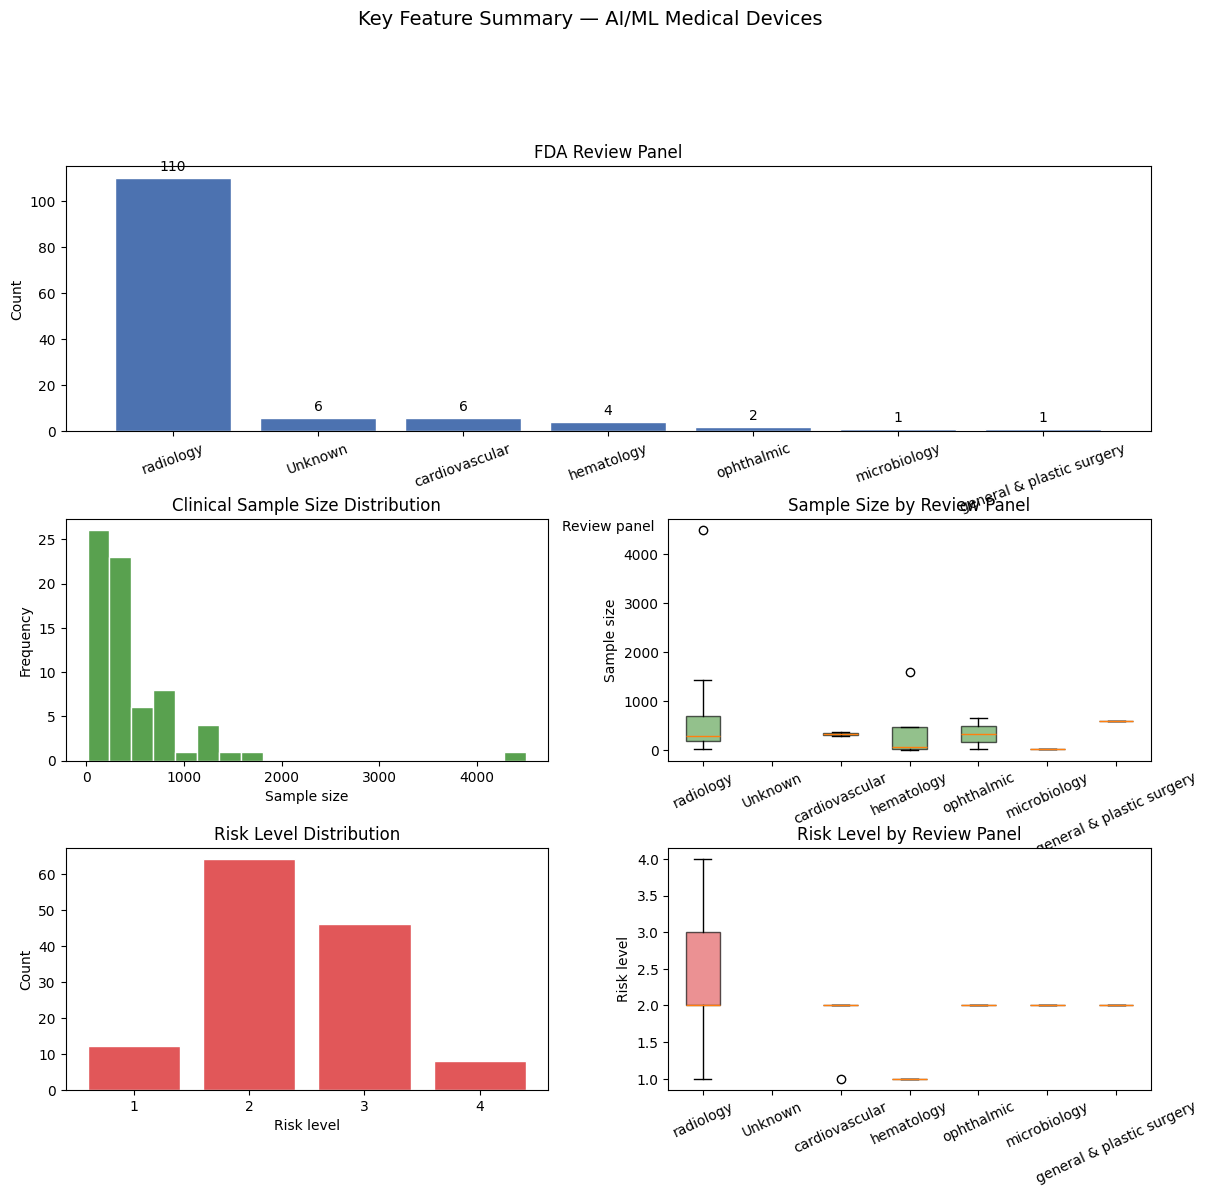

In [3]:
fig = plt.figure(figsize=(14, 12))
grid = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.35, wspace=0.25)

# Review panel categories
ax_panel = fig.add_subplot(grid[0, :])
panel_counts = aiml_df_raw["review_panel"].fillna("Unknown").value_counts().sort_values(ascending=False)
bars = ax_panel.bar(panel_counts.index, panel_counts.values, color="#4C72B0", edgecolor="white")
ax_panel.set_title("FDA Review Panel")
ax_panel.set_xlabel("Review panel")
ax_panel.set_ylabel("Count")
ax_panel.bar_label(bars, padding=3)
ax_panel.tick_params(axis="x", rotation=20)

# Sample size distribution
ax_sample_hist = fig.add_subplot(grid[1, 0])
sample_sizes = aiml_df_raw["sample_size"].dropna()
ax_sample_hist.hist(sample_sizes, bins=20, color="#59A14F", edgecolor="white")
ax_sample_hist.set_title("Clinical Sample Size Distribution")
ax_sample_hist.set_xlabel("Sample size")
ax_sample_hist.set_ylabel("Frequency")

# Sample size box plot by review panel
ax_sample_box = fig.add_subplot(grid[1, 1])
panel_order = panel_counts.index.tolist()
samples_by_panel = [
    aiml_df_raw.loc[aiml_df_raw["review_panel"] == panel, "sample_size"].dropna()
    for panel in panel_order
]
box = ax_sample_box.boxplot(
    samples_by_panel,
    labels=panel_order,
    patch_artist=True,
    vert=True,
)
for patch in box["boxes"]:
    patch.set_facecolor("#59A14F")
    patch.set_alpha(0.65)
ax_sample_box.set_title("Sample Size by Review Panel")
ax_sample_box.set_ylabel("Sample size")
ax_sample_box.tick_params(axis="x", rotation=25)

# Risk level distribution
ax_risk_hist = fig.add_subplot(grid[2, 0])
risk_counts = aiml_df_raw["risk_level"].value_counts().sort_index()
ax_risk_hist.bar(
    risk_counts.index.astype(str),
    risk_counts.values,
    color="#E15759",
    edgecolor="white",
)
ax_risk_hist.set_title("Risk Level Distribution")
ax_risk_hist.set_xlabel("Risk level")
ax_risk_hist.set_ylabel("Count")

# Risk level box plot by review panel
ax_risk_box = fig.add_subplot(grid[2, 1])
risk_by_panel = [
    aiml_df_raw.loc[aiml_df_raw["review_panel"] == panel, "risk_level"].dropna()
    for panel in panel_order
]
box = ax_risk_box.boxplot(
    risk_by_panel,
    labels=panel_order,
    patch_artist=True,
    vert=True,
)
for patch in box["boxes"]:
    patch.set_facecolor("#E15759")
    patch.set_alpha(0.65)
ax_risk_box.set_title("Risk Level by Review Panel")
ax_risk_box.set_ylabel("Risk level")
ax_risk_box.tick_params(axis="x", rotation=25)

plt.suptitle("Key Feature Summary — AI/ML Medical Devices", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()